# Single transect data organization for creating interoperable machine learning datasets for echogram classification tasks

```{admonition} This notebook accompanies the following paper:
:class: tip
**An open-source transect-based workflow for organizing fisheries acoustics data for machine learning applications**\
Authors: C. Tuguinay, W. J. Lee, V. Staneva, E. M. Phillips, J. Clemons, A. Billings, and D. Chu\
Manuscript in preparation to be submitted to Limnology and Oceanography Methods
```

## Introduction

### Description

This notebook uses a single transect of the EK60 echosounder data collected during the [2019 Joint U.S.-Canada Integrated Ecosystem and Pacific Hake Acoustic Trawl Survey (aka the "Hake survey")](https://www.fisheries.noaa.gov/west-coast/science-data/joint-us-canada-integrated-ecosystem-and-pacific-hake-acoustic-trawl-survey) to illustrate a processing pipeline for creating interoperable machine learning datasets for echogram classification tasks. The workflow includes steps to perform data conversion, calibration, uniformly gridding, and masking, using functions from [`Echopype`](https://echopype.readthedocs.io), [`Echoregions`](https://echoregions.readthedocs.io), and core scientific Python software packages, particularly `Xarray` and `Dask`. This workflow utilizes hake annotations which were manually produced from the NOAA Fisheries Northwest Fisheries Science Center (NWFSC) [Fisheries Engineering and Acoustic Technologies Team (FEAT)](https://www.fisheries.noaa.gov/west-coast/sustainable-fisheries/fisheries-engineering-and-acoustic-technologies-team).

### Outline

- [Workflow stage 1: Transect data organization](##Workflow-stage-1:-Transect-data-organization)
- [Workflow stage 2: Clean fish mask creation](##Workflow-stage-2:-Clean-fish-mask-creation)
- [Workflow extensions](##Workflow-extensions)

### Running the notebook

This notebook can be run with a conda environment created using the [conda environment file](../conda/environment-ep-main.yml). The notebook creates a directory, if not already present: `./exports/single_transect_data_organization`. All Zarr files will be exported there.

### Note
We encourage importing Echopype as `ep` for consistency.

In [1]:
# Import packages

from pathlib import Path
import re
from datetime import datetime

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import fsspec
import pandas as pd
from dask.distributed import Client

import echopype as ep
import echoregions as er

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from zarr.errors import ZarrUserWarning, UnstableSpecificationWarning
# Silence Zarr v3 warnings
warnings.filterwarnings("ignore", category=ZarrUserWarning)
warnings.filterwarnings("ignore", category=UnstableSpecificationWarning)

## Setup Dask and file directories

As most personal devices have at least 4 CPU cores and 8 GB of RAM, we demonstrate running the workflow using a local-cluster containing 2 low-resource Dask workers:
- Each worker is a separate process with 2 threads (CPU cores) for concurrent execution of tasks
- Each worker is limited to 4 GB of RAM, for a total cluster memory of 8 GB

In [2]:
client = Client(n_workers=2, threads_per_worker=2, memory_limit="4GB")

Dask Client Dashboard: http://127.0.0.1:8787/status


In [3]:
# Create directories
base_path = Path("./exports/single_transect_data_organization")
base_path.mkdir(exist_ok=True, parents=True)
echodata_zarr_path = base_path / "echodata_zarr"
echodata_zarr_path.mkdir(exist_ok=True)
combined_zarr_path = base_path / "combined_zarr"
combined_zarr_path.mkdir(exist_ok=True)

## Workflow stage 1: Transect data organization

Parse the `.evr` file using Echoregions' `read_evr` function. The parsing is based off of the `.evr` data description shown on Echoview's website: [Region Attributes](https://support.echoview.com/WebHelp/Reference/File_Formats/Export_File_Formats/2D_Region_definition_file_format.htm).

In [4]:
# Read region object
regions_object = er.read_evr("example_data/single_transect_data_organization/transect_53_year_2019_regions.evr")
regions_object.data[["region_id", "region_name", "region_class"]]

,region_id,region_name,region_class
0,1,ST53,Log
1,2,BT53,Log
2,3,RT53,Log
3,4,ET53,Log
4,5,H47U-Region 43,Hake
5,6,H47U-Region 44,Hake
6,7,H46U-Region 45,Hake
7,8,H51U-Region 46,Hake


ST stands for Start Transect, ET for End Transect, BT for Break Transect, and RT for Resume Transect. Any data collected between the intervals ST–ET, RT–ET, ST–BT, or RT–BT is considered within-transect (WT), while all other data is outside-transect (OT). Our goal is to capture the times associated with ST and ET events to subset the backscatter data, ensuring we include all data collected within the transect boundaries. Throughout this notebook, we will refer to hake as fish to emphasize that this workflow is not specific to the Hake Survey.

In [5]:
# Find time range
start_time = regions_object.select_region(region_id=1)["time"][0].min()
end_time = regions_object.select_region(region_id=4)["time"][3].max()
start_time = pd.to_datetime(start_time).to_pydatetime()
end_time = pd.to_datetime(end_time).to_pydatetime()
print("Start time:", str(start_time))
print("End time:", str(end_time))

Start time: 2019-07-23 19:17:52.423500
End time: 2019-07-24 02:26:06.458000


This code sets up access to an S3 bucket containing raw EK60 acoustic files, extracts timestamps from the filenames, and selects all files within the ST-ET time window. It also includes the first file immediately before the start time and the first file immediately after the end time to ensure full coverage of the transect range.

In [6]:
# Setup the filesystem that points to the .raw directory
fs = fsspec.filesystem("s3", anon=True)
bucket = "noaa-wcsd-pds"
rawdirpath = "data/raw/Bell_M._Shimada/SH1906/EK60"

# Regex and helper function for filenames such as SH-19-06-D20190617-T123400.raw
pattern = re.compile(r"D(\d{8})-T(\d{6})")
def extract_datetime_from_path(path):
    """
    Extract datetime from EK60 filename, e.g.:
    SH-19-06-D20190617-T121905.raw
    """
    match = pattern.search(path)
    if not match:
        return None
    date_str, time_str = match.groups()
    return datetime.strptime(date_str + time_str, "%Y%m%d%H%M%S")

# Filter files within the time window
s3rawfiles = fs.glob(f"{bucket}/{rawdirpath}/*.raw")
select_files = []
for s3path in s3rawfiles:
    ts = extract_datetime_from_path(s3path)
    if ts is not None and start_time <= ts <= end_time:
        select_files.append(s3path)

# Sort all files with timestamps and find first file before
# ST time and first file after ET time and place in select_files
all_files_with_time = []
for s3path in s3rawfiles:
    ts = extract_datetime_from_path(s3path)
    if ts is not None:
        all_files_with_time.append((ts, s3path))
all_files_with_time.sort(key=lambda x: x[0])
all_times = [t for t, _ in all_files_with_time]
all_paths = [p for _, p in all_files_with_time]
selected_times = [extract_datetime_from_path(f) for f in select_files]
selected_times_sorted = sorted(selected_times)
first_time = selected_times_sorted[0]
last_time = selected_times_sorted[-1]
first_idx = all_times.index(first_time)
last_idx = all_times.index(last_time)
file_before = all_paths[first_idx - 1] if first_idx > 0 else None
file_after = all_paths[last_idx + 1] if last_idx < len(all_paths) - 1 else None
select_files.insert(0, file_before)
select_files.append(file_after)

print(f"There are {len(select_files)} target raw files available")

There are 40 target raw files available


In [7]:
# Check sizes for selected files
file_sizes = []
for f in select_files:
    if f is not None:
        size_bytes = fs.size(f)
        file_sizes.append((f, size_bytes))

# Print results
for f, size in file_sizes:
    print(f"{f}: {size / 1e6:.2f} MB")  # size in MB

# Optional: total size of all selected files
total_size = sum(size for _, size in file_sizes)
print(f"Total size of selected files: {total_size / 1e6:.2f} MB")

noaa-wcsd-pds/data/raw/Bell_M._Shimada/SH1906/EK60/SH-19-06-D20190723-T190606.raw: 26.27 MB
noaa-wcsd-pds/data/raw/Bell_M._Shimada/SH1906/EK60/SH-19-06-D20190723-T192100.raw: 26.24 MB
noaa-wcsd-pds/data/raw/Bell_M._Shimada/SH1906/EK60/SH-19-06-D20190723-T193442.raw: 26.27 MB
noaa-wcsd-pds/data/raw/Bell_M._Shimada/SH1906/EK60/SH-19-06-D20190723-T194623.raw: 26.27 MB
noaa-wcsd-pds/data/raw/Bell_M._Shimada/SH1906/EK60/SH-19-06-D20190723-T195757.raw: 26.25 MB
noaa-wcsd-pds/data/raw/Bell_M._Shimada/SH1906/EK60/SH-19-06-D20190723-T200848.raw: 26.27 MB
noaa-wcsd-pds/data/raw/Bell_M._Shimada/SH1906/EK60/SH-19-06-D20190723-T202323.raw: 26.28 MB
noaa-wcsd-pds/data/raw/Bell_M._Shimada/SH1906/EK60/SH-19-06-D20190723-T203819.raw: 26.29 MB
noaa-wcsd-pds/data/raw/Bell_M._Shimada/SH1906/EK60/SH-19-06-D20190723-T205342.raw: 26.23 MB
noaa-wcsd-pds/data/raw/Bell_M._Shimada/SH1906/EK60/SH-19-06-D20190723-T211035.raw: 26.28 MB
noaa-wcsd-pds/data/raw/Bell_M._Shimada/SH1906/EK60/SH-19-06-D20190723-T212629.ra

### Convert EK60 `.raw` files to EchoData objects

The following data processing steps follow the typical Echopype workflow, which converts and standardizes data before performing more computation. Below we first convert and save the `.raw` files generated by EK60 to Zarr stores on disk, and lazy-load them back for downstream processing. This allows the machine to perform computations that may require resources that are larger than the local system memory.

More information on lazy loading can be found [here](https://en.wikipedia.org/wiki/Lazy_loading).

The execution time of the following code largely depends on the connection to the S3 bucket:

In [8]:
%%time

# Save EchoData objects locally
def open_and_save(raw_file, sonar_model, use_swap, save_path, storage_options):
    # Silence Zarr v3 warnings inside each future as filters are not inherited
    # from the main process.
    warnings.filterwarnings("ignore", category=ZarrUserWarning)
    warnings.filterwarnings("ignore", category=UnstableSpecificationWarning)
    try:
        ed = ep.open_raw(
            raw_file=f's3://{raw_file}',
            sonar_model=sonar_model,
            use_swap=use_swap,
            storage_options=storage_options,
        )
        ed.to_zarr(
            save_path,
            overwrite=True,
            compute=True,
            compress=False,
        )
    except Exception as e:
        print("Error with Exception: ", e)

# Parse EK60 `.RAW` file and save to Zarr Store
open_and_save_futures = []
for raw_file_url in select_files:
    open_and_save_future = client.submit(
        open_and_save,
        raw_file=raw_file_url,
        sonar_model='EK60',
        use_swap=True,
        save_path=echodata_zarr_path,
        storage_options={'anon': True}
    )
    open_and_save_futures.append(open_and_save_future)
open_and_save_futures = client.gather(open_and_save_futures)

/home/ctuguinay/miniforge3/envs/echopype-examples/lib/python3.12/site-packages/echopype/convert/set_groups_ek60.py:710: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'ping_time' ('ping_time',) The recommendation is to set join explicitly for this case.
  [ds, xr.concat(ds_backscatter, dim="channel")], combine_attrs="override"


CPU times: user 16.4 s, sys: 2.32 s, total: 18.8 s
Wall time: 3min 53s


In [9]:
%%time

# Open (lazy-load) Zarr stores containing EchoData Objects, and lazily combine them
ed_future_list = []
for converted_file in sorted(echodata_zarr_path.glob("*.zarr")):
    ed_future = client.submit(    
        ep.open_converted,
        converted_raw_path=converted_file,
        chunks={}
    )
    ed_future_list.append(ed_future)
ed_list = client.gather(ed_future_list)

CPU times: user 1.45 s, sys: 133 ms, total: 1.58 s
Wall time: 8.38 s


### Combine EchoData objects

Under the hood of the `ep.combine_echodata` function, the Zarr stores of each EchoData object are loaded and appended lazily, meaning that no data loading or appending happens until the combined object is saved to disk via `to_zarr`.

In [10]:
%%time

# Lazily combine echodata objects
ed_combined = ep.combine_echodata(ed_list)

# Save the combined EchoData object to a new Zarr store
ed_combined.to_zarr(
    combined_zarr_path / "ed_combined.zarr",
    overwrite=True,
    compute=True,
    compress=False,
    align_chunks=True,
)

# Lazy-load the comined Zarr store
ed_combined = ep.open_converted(
    combined_zarr_path / "ed_combined.zarr",
    chunks={},
)

/home/ctuguinay/miniforge3/envs/echopype-examples/lib/python3.12/site-packages/echopype/utils/io.py:79: SerializationWarning: saving variable None with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds.to_zarr(store=path.root, mode=mode, group=group, encoding=encoding, **kwargs)


CPU times: user 1min 4s, sys: 4.91 s, total: 1min 9s
Wall time: 2min 5s


### Calibrate raw backscatter measurements in the combined EchoData object to Sv

Compute Volume Backscattering Strength (Sv) from raw backscatter measurements stored in the converted EchoData object, and add depth and latitude/longitude to this dataset.

In [55]:
# Compute Sv
ds_Sv = ep.calibrate.compute_Sv(ed_combined)

We show that the calibrated backscatter data that has been lazily-computed. This means that no calibration has been performed, but the steps to calibrate have been planned. Note the number of chunks and graph layers. Each chunk is a disk-saved partition of the raw backscatter data, and the number of graph layers is the number of computations needed to calibrate each chunk of the raw data. Each dask worker generally operates on a single chunk, so having more workers (i.e., more computational resources) will process more chunks in parallel. This is another way we achieve scalability throughout this workflow.

In [53]:
ds_Sv["Sv"]

<xarray.DataArray 'Sv' (channel: 5, ping_time: 13047, range_sample: 3957)> Size: 2GB
dask.array<sub, shape=(5, 13047, 3957), dtype=float64, chunksize=(1, 325, 3957), chunktype=numpy.ndarray>
Coordinates:
  * channel       (channel) <U37 740B 'GPT  18 kHz 009072058c8d 1-1 ES18-11' ...
  * ping_time     (ping_time) datetime64[ns] 104kB 2019-07-23T19:06:06.472269...
  * range_sample  (range_sample) int64 32kB 0 1 2 3 4 ... 3953 3954 3955 3956
Attributes:
    long_name:  Volume backscattering strength (Sv re 1 m-1)
    units:      dB

In [ ]:
%%time

# Add Depth
ds_Sv = ep.consolidate.add_depth(ds_Sv, depth_offset=9.15)

# Add Latitude and Longitude
ds_Sv = ep.consolidate.add_location(ds_Sv, ed_combined)

# Save to Zarr and offload computation to disk
ds_Sv.to_zarr(
    combined_zarr_path / "ds_Sv.zarr",
    mode="w",
    compute=True,
    align_chunks=True,
)

# Lazy-load the Zarr store
ds_Sv = xr.open_dataset(
    combined_zarr_path / "ds_Sv.zarr",
    engine="zarr",
    chunks={},
)

The user can optionally identify and remove noise from the Sv data using a myriad of functions from the `echopype.clean` subpackage. In particular, the `transient_noise.ipynb` notebook details how to identify and remove transient noise from the Sv data. The Hake Survey echo data contains very little noise so we do not demonstrate this functionality here.

### Transect-based splitting

As previously shown, the regions object contains transect information. We can use this to create a transect mask for the calibrated backscatter data, where a value of `1` indicates WT data and a value of `0` indicates OT data.

In [12]:
transect_mask = regions_object.transect_mask(
    ds_Sv["Sv"],
)

We can plot the transect mask for the calibrated backscatter dataset:
- WT is shown in yellow (1) 
- OT is shown in purple (0)

The transect mask is uniform across range sample so we can visualize a small range sample slice.

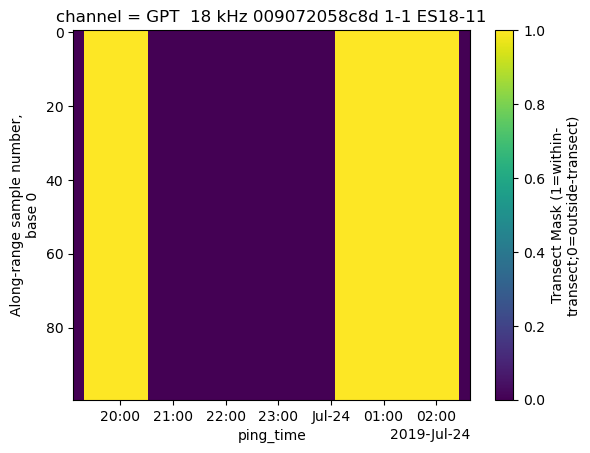

In [13]:
transect_mask.isel(
    range_sample=slice(0, 100)
).plot(yincrease=False, y="range_sample")

Find WT segment times:

In [14]:
%%time

# Find time indices where mask is 1
target_indices = np.where(
    transect_mask.isel(range_sample=0).values == 1
)[0]

# Split into two groups by finding the largest gap
gaps = np.diff(target_indices)
split_idx = np.argmax(gaps) # index where the gap is largest

# Grab WT times
first_WT_times = transect_mask.isel(
    ping_time=target_indices[:split_idx+1]
)["ping_time"].drop_vars("channel")
second_WT_times = transect_mask.isel(
    ping_time=target_indices[split_idx+1:]
)["ping_time"].drop_vars("channel")

CPU times: user 317 ms, sys: 24.8 ms, total: 341 ms
Wall time: 552 ms


Note that the data collection timestamps are in GMT, but the survey was conducted during PST.

In [15]:
first_WT_times

<xarray.DataArray 'ping_time' (ping_time: 1867)> Size: 15kB
array(['2019-07-23T19:17:53.794107000', '2019-07-23T19:17:56.557264000',
       '2019-07-23T19:17:59.321423000', ..., '2019-07-23T20:31:08.904371000',
       '2019-07-23T20:31:11.665531000', '2019-07-23T20:31:14.424688000'],
      shape=(1867,), dtype='datetime64[ns]')
Coordinates:
  * ping_time  (ping_time) datetime64[ns] 15kB 2019-07-23T19:17:53.794107 ......

In [16]:
second_WT_times

<xarray.DataArray 'ping_time' (ping_time: 4917)> Size: 39kB
array(['2019-07-24T00:04:38.494974000', '2019-07-24T00:04:41.259130000',
       '2019-07-24T00:04:44.022289000', ..., '2019-07-24T02:26:00.803324000',
       '2019-07-24T02:26:02.418417000', '2019-07-24T02:26:04.034510000'],
      shape=(4917,), dtype='datetime64[ns]')
Coordinates:
  * ping_time  (ping_time) datetime64[ns] 39kB 2019-07-24T00:04:38.494974 ......

In [17]:
%%time

# Split WT segments
ds_first_WT_Sv = ds_Sv.sel(ping_time=first_WT_times.values)
ds_second_WT_Sv = ds_Sv.sel(ping_time=second_WT_times.values)

# Save to Zarr stores and offload computation to disk
first_Sv_filename = "ds_first_WT_Sv.zarr"
second_Sv_filename = "ds_second_WT_Sv.zarr"
ds_first_WT_Sv.to_zarr(
    combined_zarr_path / first_Sv_filename,
    mode="w",
    compute=True,
    align_chunks=True,
)
ds_second_WT_Sv.to_zarr(
    combined_zarr_path / second_Sv_filename,
    mode="w",
    compute=True,
    align_chunks=True,
)

# Lazy-load the Zarr stores
ds_first_WT_Sv = xr.open_dataset(
    combined_zarr_path / first_Sv_filename,
    engine="zarr",
    chunks={},
)
ds_second_WT_Sv = xr.open_dataset(
    combined_zarr_path / second_Sv_filename,
    engine="zarr",
    chunks={},
)

CPU times: user 9.37 s, sys: 1.15 s, total: 10.5 s
Wall time: 20.2 s


### Uniformly grid Sv to MVBS

For each WT segment, we create a uniform time-depth grid for each frequency by computing the mean volume backscattering strength (MVBS), which are time-depth binned averages of the (linear) volume backscattering coefficient.

In [18]:
%%time

# Compute MVBS
ds_first_WT_MVBS = ep.commongrid.compute_MVBS(
    ds_first_WT_Sv,
    range_var="depth",
    range_bin="1m",
    ping_time_bin="5s",
    range_var_max="760m",
)

# Save to Zarr and offload computation to disk
first_mvbs_filename = "ds_first_WT_MVBS.zarr"
ds_first_WT_MVBS.to_zarr(
    combined_zarr_path / first_mvbs_filename,
    mode="w",
    compute=True,
    align_chunks=True,
)

# Lazy-load the Zarr store
ds_first_WT_MVBS = xr.open_dataset(
    combined_zarr_path / first_mvbs_filename,
    engine="zarr",
    chunks={},
    consolidated=False,
)

CPU times: user 1.21 s, sys: 159 ms, total: 1.37 s
Wall time: 11.9 s


In [19]:
%%time

# Compute MVBS
ds_second_WT_MVBS = ep.commongrid.compute_MVBS(
    ds_second_WT_Sv,
    range_var="depth",
    range_bin="1m",
    ping_time_bin="5s",
    range_var_max="760m",
)

# Save to Zarr and offload computation to disk
second_mvbs_filename = "ds_second_WT_MVBS.zarr"
ds_second_WT_MVBS.to_zarr(
    combined_zarr_path / second_mvbs_filename,
    mode="w",
    compute=True,
    align_chunks=True,
)

# Lazy-load the Zarr stores
ds_second_WT_MVBS = xr.open_dataset(
    combined_zarr_path / second_mvbs_filename,
    engine="zarr",
    chunks={},
    consolidated=False,
)

CPU times: user 2.66 s, sys: 322 ms, total: 2.98 s
Wall time: 29 s


Previously, we had added latitude and longitude data into the Sv data. When calling `ep.commongrid.compute_MVBS` on the Sv data, we also regrid the latitude and longitude data to match the new uniform time grid. We check below that the new latitude and longitude data share the same time coordinates (`ping_time`) as the uniform time-depth grid echo data:

In [20]:
ds_first_WT_MVBS

<xarray.Dataset> Size: 27MB
Dimensions:            (ping_time: 881, channel: 5, depth: 761)
Coordinates:
  * ping_time          (ping_time) datetime64[ns] 7kB 2019-07-23T19:17:50 ......
  * channel            (channel) <U37 740B 'GPT  18 kHz 009072058c8d 1-1 ES18...
  * depth              (depth) float64 6kB 0.0 1.0 2.0 3.0 ... 758.0 759.0 760.0
Data variables:
    latitude           (ping_time) float64 7kB dask.array<chunksize=(881,), meta=np.ndarray>
    longitude          (ping_time) float64 7kB dask.array<chunksize=(881,), meta=np.ndarray>
    frequency_nominal  (channel) float64 40B dask.array<chunksize=(5,), meta=np.ndarray>
    Sv                 (channel, ping_time, depth) float64 27MB dask.array<chunksize=(5, 881, 761), meta=np.ndarray>
Attributes:
    processing_software_name:     echopype
    processing_software_version:  0.8.2.dev463+gfc66dc088
    processing_time:              2026-04-08T19:25:12+00:00
    processing_function:          commongrid.compute_MVBS
    processing_level:             Level 3A
    processing_level_url:         https://echopype.readthedocs.io/en/stable/p...

In [21]:
ds_second_WT_MVBS

<xarray.Dataset> Size: 52MB
Dimensions:            (ping_time: 1698, channel: 5, depth: 761)
Coordinates:
  * ping_time          (ping_time) datetime64[ns] 14kB 2019-07-24T00:04:35 .....
  * channel            (channel) <U37 740B 'GPT  18 kHz 009072058c8d 1-1 ES18...
  * depth              (depth) float64 6kB 0.0 1.0 2.0 3.0 ... 758.0 759.0 760.0
Data variables:
    latitude           (ping_time) float64 14kB dask.array<chunksize=(1698,), meta=np.ndarray>
    frequency_nominal  (channel) float64 40B dask.array<chunksize=(5,), meta=np.ndarray>
    longitude          (ping_time) float64 14kB dask.array<chunksize=(1698,), meta=np.ndarray>
    Sv                 (channel, ping_time, depth) float64 52MB dask.array<chunksize=(5, 1698, 761), meta=np.ndarray>
Attributes:
    processing_software_name:     echopype
    processing_software_version:  0.8.2.dev463+gfc66dc088
    processing_time:              2026-04-08T19:25:24+00:00
    processing_function:          commongrid.compute_MVBS
    processing_level:             Level 3A
    processing_level_url:         https://echopype.readthedocs.io/en/stable/p...

We can also check longitude extent and average latitude of the WT segments. We expect the latitudes to be close to equal across the transect segments as the transect is oriented east-west:

In [22]:
first_WT_start_lon = float(ds_first_WT_MVBS["longitude"].min().values)
first_WT_end_lon = float(ds_first_WT_MVBS["longitude"].max().values)
print(
    f"First WT segment longitude range: {first_WT_start_lon:.3f}° to {first_WT_end_lon:.3f}°"
)
first_WT_mean_lat = float(ds_first_WT_MVBS["latitude"].mean().values)
print(
    f"First WT segment mean latitude: {first_WT_mean_lat:.3f}°"
)

First WT segment longitude range: -125.280° to -124.979°
First WT segment mean latitude: 43.063°


In [23]:
second_WT_start_lon = float(ds_second_WT_MVBS["longitude"].min().values)
second_WT_end_lon = float(ds_second_WT_MVBS["longitude"].max().values)
print(
    f"Second WT segment longitude range: {second_WT_start_lon:.3f}° to {second_WT_end_lon:.3f}°."
)
second_WT_mean_lat = float(ds_second_WT_MVBS["latitude"].mean().values)
print(
    f"Second WT segment mean latitude: {second_WT_mean_lat:.3f}°"
)

Second WT segment longitude range: -124.980° to -124.483°.
Second WT segment mean latitude: 43.064°


## Workflow stage 2: Clean fish mask creation

Parse the `.evl` file using Echoregions' `read_evl` function. The parsing is based on the `.evl` data description shown on Echoview's website: [Line Attributes](https://support.echoview.com/WebHelp/Using_Echoview/Exporting/Exporting_Data/Exporting_line_data.htm).

In [24]:
line_object = er.read_evl(
    "example_data/single_transect_data_organization/transect_53_year_2019_seafloor.evl"
)

Apply 1m offset to include more seafloor when masking:

In [25]:
line_object.data["depth"] = line_object.data["depth"].apply(
    lambda x: x - 1
)

Plot the first WT segment’s midwater fish region annotation (lime color for `region_id=5`) with the 38kHz MVBS data. The seafloor is beyond the echo range so there are no seafloor annotations.

In [26]:
ds_first_WT_MVBS["channel"]

<xarray.DataArray 'channel' (channel: 5)> Size: 740B
array(['GPT  18 kHz 009072058c8d 1-1 ES18-11',
       'GPT  38 kHz 009072060fbe 2-1 ES38B',
       'GPT  70 kHz 00907205da30 3-1 ES70-7C',
       'GPT 120 kHz 00907205a6d0 4-1 ES120-7C',
       'GPT 200 kHz 00907205aec4 5-1 ES200-7C'], dtype='<U37')
Coordinates:
  * channel  (channel) <U37 740B 'GPT  18 kHz 009072058c8d 1-1 ES18-11' ... '...
Attributes:
    long_name:  Vendor channel ID

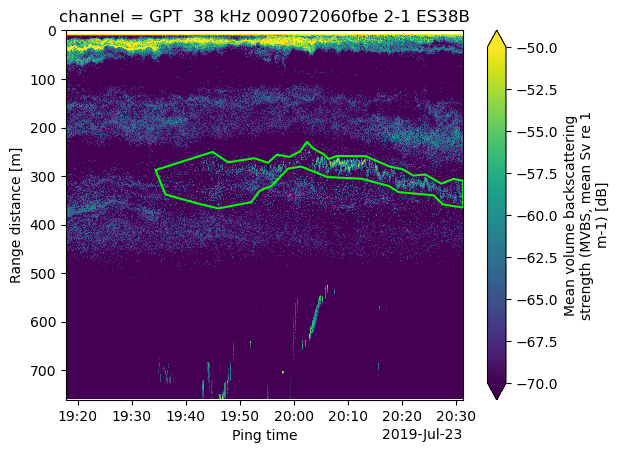

In [27]:
regions_object.plot(region_id=5, close_regions=True, color="lime")
ds_first_WT_MVBS["Sv"].sel(
    channel="GPT  38 kHz 009072060fbe 2-1 ES38B"
).plot(
    yincrease=False,
    y="depth",
    vmax=-50,
    vmin=-70,
)

Plot the second WT segment's near-seafloor fish region annotations (lime for `region_id=6`, cyan for `region_id=7`, and white for `region_id=8`) and seafloor annotation (red) with the 38kHz MVBS data:

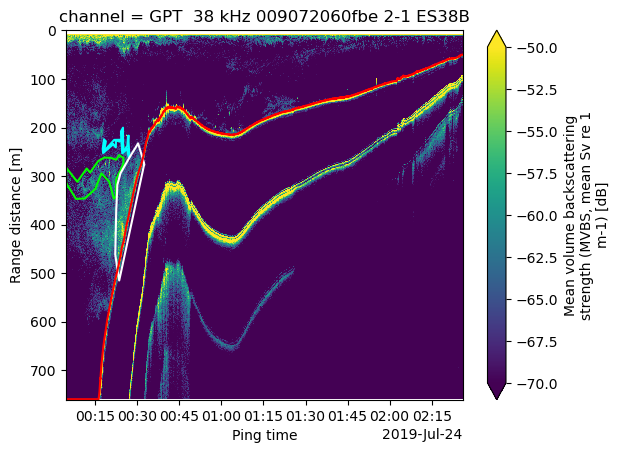

In [28]:
regions_object.plot(
    region_id=6,
    close_regions=True,
    color="lime"
)
regions_object.plot(
    region_id=7,
    close_regions=True,
    color="cyan"
)
regions_object.plot(
    region_id=8,
    close_regions=True,
    color="white"
)
line_object.plot(color="red")
ds_second_WT_MVBS["Sv"].sel(
    channel="GPT  38 kHz 009072060fbe 2-1 ES38B"
).plot(
    yincrease=False,
    y="depth",
    vmax=-50,
    vmin=-70,
)

Zoomed-in view of the fish and seafloor intersection:

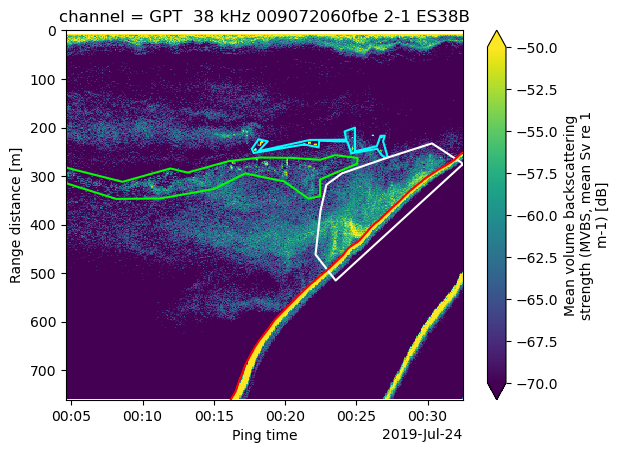

In [29]:
min_time = regions_object.select_region(
    region_id=[6, 7, 8]
)["region_bbox_left"].min()
max_time = regions_object.select_region(
    region_id=[6, 7, 8]
)["region_bbox_right"].max()
regions_object.plot(
    region_id=6,
    close_regions=True,
    color="lime"
)
regions_object.plot(
    region_id=7,
    close_regions=True,
    color="cyan"
)
regions_object.plot(
    region_id=8,
    close_regions=True,
    color="white"
)
line_object.plot(start_time=min_time, end_time=max_time, color="red")
ds_second_WT_MVBS["Sv"].sel(
    channel="GPT  38 kHz 009072060fbe 2-1 ES38B"
).sel(ping_time=slice(min_time, max_time)).plot(
    yincrease=False,
    y="depth",
    vmax=-50,
    vmin=-70,
)

The `region_id=8` fish region has seafloor that we will need to remove.

The region and seafloor annotations operate with `depth` and not `range_sample`, so we must replace `range_sample` with `depth`. This function extracts a 1D `depth` coordinate from the Sv dataset and assigns it as the new `depth` dimension.

In [30]:
def _replace_range_sample_with_depth(_ds_Sv):
    depth_1d = _ds_Sv["depth"].sel(
        channel="GPT  38 kHz 009072060fbe 2-1 ES38B"
    ).isel(ping_time=0)
    _ds_Sv["depth"] = depth_1d
    _ds_Sv = _ds_Sv.swap_dims({"range_sample": "depth"})
    return _ds_Sv

In [31]:
# Replace range sample with depth in Sv data
ds_first_WT_Sv = _replace_range_sample_with_depth(ds_first_WT_Sv)
ds_second_WT_Sv = _replace_range_sample_with_depth(ds_second_WT_Sv)

### Create region and seafloor masks

Create first WT segment's fish region mask:

In [32]:
# Mask region
ds_first_WT_fish_regions, _ = regions_object.region_mask(
    ds_first_WT_Sv["Sv"].isel(channel=0), region_id=[5]
)

# Save to Zarr and offload computation to disk
ds_first_WT_fish_regions.to_zarr(
    combined_zarr_path / "ds_first_WT_fish_regions.zarr",
    mode="w",
    compute=True,
    align_chunks=True,
)

# Lazy-load the Zarr store
ds_first_WT_fish_regions = xr.open_dataset(
    combined_zarr_path / "ds_first_WT_fish_regions.zarr",
    engine="zarr",
    chunks={},
)

Create second WT segment's fish region masks:

In [33]:
# Mask regions
ds_second_WT_fish_regions, _ = regions_object.region_mask(
    ds_second_WT_Sv["Sv"], region_id=[6, 7, 8]
)

# Save to Zarr and offload computation to disk
ds_second_WT_fish_regions.to_zarr(
    combined_zarr_path / "ds_second_WT_fish_regions.zarr",
    mode="w",
    compute=True,
    align_chunks=True,
)

# Lazy-load the Zarr store
ds_second_WT_fish_regions = xr.open_dataset(
    combined_zarr_path / "ds_second_WT_fish_regions.zarr",
    engine="zarr",
    chunks={},
)

Create second WT segment's seafloor mask:

In [34]:
# Mask seafloor
ds_second_WT_seafloor, _ = line_object.seafloor_mask(ds_second_WT_Sv["Sv"])

# Save to Zarr and offload computation to disk
ds_second_WT_seafloor.to_zarr(
    combined_zarr_path / "ds_second_WT_seafloor.zarr",
    mode="w",
    compute=True,
    align_chunks=True,
)

# Lazy-load the Zarr store
ds_second_WT_seafloor = xr.open_dataset(
    combined_zarr_path / "ds_second_WT_seafloor.zarr",
    engine="zarr",
    chunks={},
)

### Remove seafloor contamination from fish region masks

Apply seafloor removal to the second WT segment's fish region masks:

In [35]:
# Seafloor removal
da_second_WT_clean_fish_regions = xr.where(
    ds_second_WT_seafloor["mask"] == 0,
    ds_second_WT_fish_regions["mask_3d"],
    0,
)
ds_second_WT_clean_fish_regions = da_second_WT_clean_fish_regions.to_dataset(
    name="mask_3d"
)

# Save to Zarr and offload computation to disk
ds_second_WT_clean_fish_regions.to_zarr(
    combined_zarr_path / "ds_second_WT_clean_fish_regions.zarr",
    mode="w",
    compute=True,
    align_chunks=True,
)

# Lazy-load the Zarr store
ds_second_WT_clean_fish_regions = xr.open_dataset(
    combined_zarr_path / "ds_second_WT_clean_fish_regions.zarr",
    engine="zarr",
    chunks={},
)

The `region_id = 8` fish region should be the only region that has changed with this seafloor removal operation:

In [36]:
# Assert equality for `region_id` 6 and 7
assert ds_second_WT_fish_regions["mask_3d"].sel(region_id=6).equals(
    ds_second_WT_clean_fish_regions["mask_3d"].sel(region_id=6)
)

assert ds_second_WT_fish_regions["mask_3d"].sel(region_id=7).equals(
    ds_second_WT_clean_fish_regions["mask_3d"].sel(region_id=7)
)

assert not ds_second_WT_fish_regions["mask_3d"].sel(region_id=8).equals(
    ds_second_WT_clean_fish_regions["mask_3d"].sel(region_id=8)
)

Check that no intersections exist between the clean region masks and the seafloor masks:

In [37]:
number_of_intersections = int(
    xr.where(
        (ds_second_WT_seafloor["mask"] == 1) & \
        (ds_second_WT_clean_fish_regions["mask_3d"].sel(region_id=8) == 1),
        1,
        0,
    ).sum().compute()
)
print(
    "Number of intersections between the clean fish region masks and the seafloor mask:",
    number_of_intersections
)

Number of intersections between the clean fish region masks and the seafloor mask: 0


### Regrid the clean fish masks onto uniform time-depth grid to match the MVBS data

In [38]:
# First WT fish regions are clean without seafloor removal so we can
# reference the mask as being cleaned
ds_first_WT_clean_fish_regions = ds_first_WT_fish_regions

# Regrid using the same dimensions as the MVBS data
da_first_WT_uniform_clean_fish_regions = ep.mask.regrid_mask(
    ds_first_WT_clean_fish_regions["mask_3d"],
    range_da=ds_second_WT_Sv["depth"],
    third_dim="region_id",
    range_bin="1m",
    ping_time_bin="5s",
    func="logical-AND",
    range_var_max="760m",
)
ds_first_WT_uniform_clean_fish_regions = da_first_WT_uniform_clean_fish_regions.to_dataset(
    name="mask_3d"
)

# Save to Zarr and offload computation to disk
ds_first_WT_uniform_clean_fish_regions.to_zarr(
    combined_zarr_path / "ds_first_WT_uniform_clean_fish_regions.zarr",
    mode="w",
    compute=True,
    align_chunks=True,
)

# Lazy-load the Zarr store
ds_first_WT_uniform_clean_fish_regions = xr.open_dataset(
    combined_zarr_path / "ds_first_WT_uniform_clean_fish_regions.zarr",
    engine="zarr",
    chunks={},
)

In [39]:
# Regrid using the same dimensions as the MVBS data
da_second_WT_uniform_clean_fish_regions = ep.mask.regrid_mask(
    ds_second_WT_clean_fish_regions["mask_3d"],
    range_da=ds_second_WT_Sv["depth"],
    third_dim="region_id",
    range_bin="1m",
    ping_time_bin="5s",
    func="logical-AND",
    range_var_max="760m",
)
ds_second_WT_uniform_clean_fish_regions = da_second_WT_uniform_clean_fish_regions.to_dataset(
    name="mask_3d"
)

# Save to Zarr and offload computation to disk
ds_second_WT_uniform_clean_fish_regions.to_zarr(
    combined_zarr_path / "ds_second_WT_uniform_clean_fish_regions.zarr",
    mode="w",
    compute=True,
    align_chunks=True,
)

# Lazy-load the Zarr store
ds_second_WT_uniform_clean_fish_regions = xr.open_dataset(
    combined_zarr_path / "ds_second_WT_uniform_clean_fish_regions.zarr",
    engine="zarr",
    chunks={},
)

Check that the uniform grid mask dimensions match the MVBS dimensions:

In [40]:
assert ds_first_WT_uniform_clean_fish_regions["depth"].equals(
    ds_first_WT_MVBS["depth"]
)
assert ds_first_WT_uniform_clean_fish_regions["ping_time"].equals(
    ds_first_WT_MVBS["ping_time"]
)

In [41]:
assert ds_second_WT_uniform_clean_fish_regions["depth"].equals(
    ds_second_WT_MVBS["depth"]
)
assert ds_second_WT_uniform_clean_fish_regions["ping_time"].equals(
    ds_second_WT_MVBS["ping_time"]
)

Plot the uniform grid clean fish mask regions:

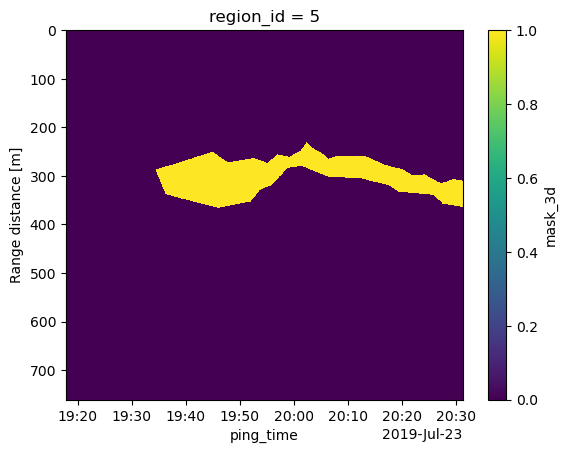

In [42]:
ds_first_WT_uniform_clean_fish_regions["mask_3d"].plot(yincrease=False, y="depth")

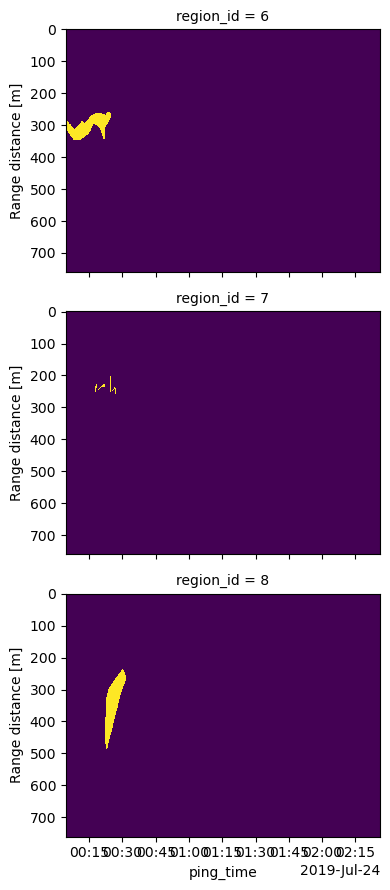

In [43]:
ds_second_WT_uniform_clean_fish_regions["mask_3d"].plot(
    yincrease=False,
    y="depth",
    row="region_id",
    # remove colorbar from rhs that encompasses the entire vertical axis
    add_colorbar=False,
)

### Converting instance segmentation masks to semantic segmentation masks

For the second WT segment, the regions are currently separated into 3 masks in the `mask_3d` DataArray. This is the format that is used for instance segmentation, as the algorithm assigns each pixel a predefined class label (e.g., fish) and distinguishes between individual objects of the same class. In contrast, semantic segmentation assigns each pixel a class label without distinguishing between objects of the same class.

We demonstrate how to convert `mask_3d` into a mask fit for semantic segmentation:

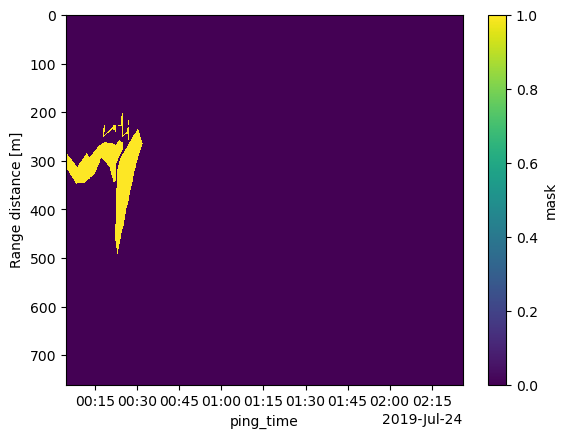

In [44]:
ds_second_WT_uniform_clean_fish_regions["mask"] = ds_second_WT_uniform_clean_fish_regions["mask_3d"].any(
    dim="region_id"
)
ds_second_WT_uniform_clean_fish_regions["mask"].plot(
    yincrease=False, y="depth",
)

### Bounding boxes for object detection

For each region of the second WT segment, we shrink the corresponding region mask such to contain the minimum amount of time-depth coordinates to encompass the non-background portion of the region. We then select the minimum and maximum of these reduced coordinates to define the bounding box vertices for object detection.

In [45]:
vertices = {}
boolean_mask = ds_second_WT_uniform_clean_fish_regions[
    "mask_3d"
].astype(bool).compute()
for region_id in boolean_mask["region_id"]:
    boolean_mask_sliced = boolean_mask.sel(
        region_id=region_id
    ).where(
        boolean_mask.sel(region_id=region_id),
        # `drop=True` ensures reduction of the mask coordinates
        drop=True,
    )
    min_depth = boolean_mask_sliced["depth"].min().values.item()
    max_depth = boolean_mask_sliced["depth"].max().values.item()
    min_ping_time = boolean_mask_sliced["ping_time"].min().values
    max_ping_time = boolean_mask_sliced["ping_time"].max().values
    # Add a small offset so that the left side of the bounding box
    # for `region_id=6` is not on the first time coordinate of
    # the mask:
    if region_id == 6:
        min_ping_time += np.timedelta64(5, "s")
    vertices[int(region_id)] = {
        "top_left": (min_depth, min_ping_time),
        "top_right": (min_depth, max_ping_time),
        "bottom_left": (max_depth, min_ping_time),
        "bottom_right": (max_depth, max_ping_time),
    }

Plot the bounding boxes defined by the vertices alongside the semantic segmentation mask:

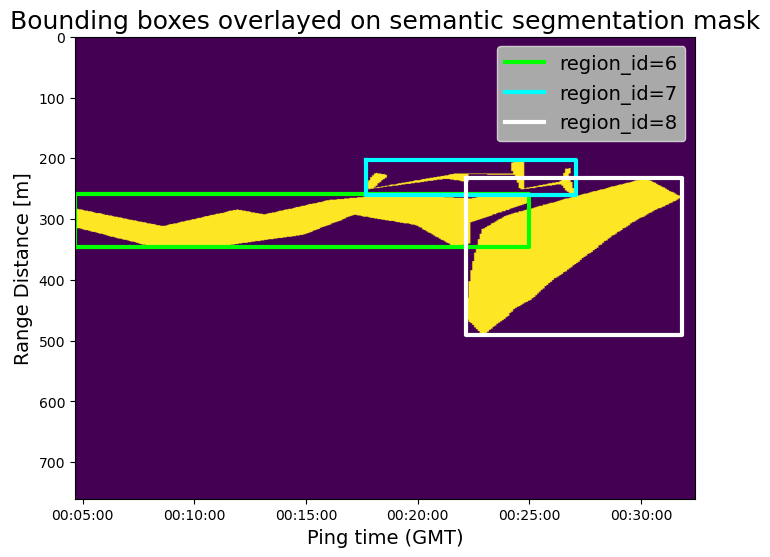

In [46]:
# Define plot size
fig, ax = plt.subplots(figsize=(8, 6))

# Plot mask using image show
mask = ds_second_WT_uniform_clean_fish_regions["mask"].sel(
    ping_time=slice(min_time, max_time)
)
depths = mask["depth"].values
ping_times = mask["ping_time"].values
mask_values = mask.values.T
extent = [
    ping_times.min(),
    ping_times.max(),
    depths.max(),
    depths.min(),
]
im = ax.imshow(
    mask_values,
    extent=extent,
    aspect="auto",
    cmap="viridis",
)

# Overlay regions
region_colors = {6: "lime", 7: "cyan", 8: "white"}
for region_id, verts in vertices.items():
    bounding_box = [
        verts["top_left"],
        verts["top_right"],
        verts["bottom_right"],
        verts["bottom_left"],
        verts["top_left"],
    ]
    depths_box, ping_times_box = zip(*bounding_box)
    ax.plot(
        ping_times_box,
        depths_box,
        color=region_colors[region_id],
        linewidth=3,
        label=f"region_id={region_id}"
    )
ax.set_xlabel("Ping time (GMT)", fontsize=14)
ax.set_ylabel("Range Distance [m]", fontsize=14)
ax.legend(fontsize=14, facecolor='darkgray', framealpha=1)
ax.set_title(
    "Bounding boxes overlayed on semantic segmentation mask",
    fontsize=18
)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.show()

In [47]:
from datetime import datetime, timezone

print(f"echopype: {ep.__version__}, xarray: {xr.__version__}")
print(f"\n{datetime.now(timezone.utc)}")

echopype: 0.8.2.dev463+gfc66dc088, xarray: 2026.2.0

2026-04-08 19:26:49.418305+00:00
